# PMMA 800µm Single Repetition (Alone)

_This notebook explores nano-FTIR measurements of PMMA deposited on Pt/SiO₂, examining spectral quality, SNR behavior, and contrast effects based on scan resolution and acquisition parameters._

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fftpack import fft, fftfreq, ifft
from scipy.optimize import curve_fit

In [3]:
def einlesen(textdatei):
    df = pd.read_csv(textdatei, sep = '\t', skiprows = 29, header = 0, engine= 'python')
    data = df[['Wavenumber', 'O2A', 'O2P','Omega']].to_numpy()
    #A= df['02A']
    #P= df['02p']
    return data

In [26]:
data=einlesen('2020-06-23 192624 NF S Deep3_PMMA_on_Pt_BK_121mA_PMMA.txt')
#print(einlesen('2020-06-23 192624 NF S Deep3_PMMA_on_Pt_BK_121mA_PMMA.txt'))

n=0
P1 = np.zeros((1199, 1)) 
A1= np.zeros((1199, 1))
W1=np.zeros((1199, 1))
for i in range (n,n+1199):
    P1[i-n]= data[i,2]
    A1[i-n]= data[i,1]
    W1[i-n]= data [i,0]
    
data=einlesen('2020-06-23 193614 NF S Deep3_PMMA_on_Pt_BK_121mA_PMMA.txt')
#print(einlesen('2020-06-23 193902 NF S Deep3_PMMA_on_Pt_BK_115mA_PMMA.txt'))

n=0
P2 = np.zeros((1199, 1)) 
A2= np.zeros((1199, 1))
W2=np.zeros((1199, 1))
for i in range (n,n+1199):
    P2 [i-n]= data[i,2]
    A2[i-n]= data[i,1]
    W2[i-n]= data [i,0]
    
data=einlesen('2020-06-23 193902 NF S Deep3_PMMA_on_Pt_BK_115mA_PMMA.txt')
#print(einlesen('2020-06-23 193902 NF S Deep3_PMMA_on_Pt_BK_115mA_PMMA.txt'))

n=0
P3 = np.zeros((1199, 1)) 
A3= np.zeros((1199, 1))
W3=np.zeros((1199, 1))
for i in range (n,n+1199):
    P3 [i-n]= data[i,2]
    A3[i-n]= data[i,1]
    W3[i-n]= data [i,0]

data=einlesen('2020-06-23 194103 NF S Deep3_PMMA_on_Pt_BK_115mA_PMMA.txt')
#print(einlesen('2020-06-23 194103 NF S Deep3_PMMA_on_Pt_BK_115mA_PMMA.txt'))

n=0
P4 = np.zeros((1199, 1)) 
A4= np.zeros((1199, 1))
W4=np.zeros((1199, 1))
for i in range (n,n+1199):
    P4 [i-n]= data[i,2]
    A4[i-n]= data[i,1]
    W4[i-n]= data [i,0] 

Text(0.5, 0, 'Wavenumber')

<Figure size 432x288 with 0 Axes>

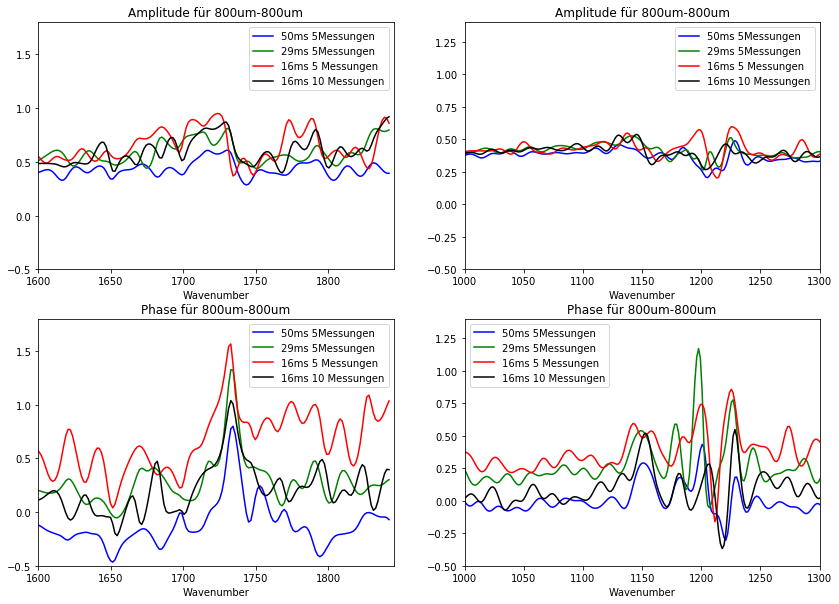

In [30]:
%matplotlib inline
plt.subplots_adjust(wspace=0.5,hspace=0.5)

plt.figure(figsize=(14,10)) 

plt.subplot(221) 
plt.plot(W1, A1, 'b-', label='50ms 5Messungen')
plt.plot(W2, A2, 'g-', label='29ms 5Messungen')
plt.plot(W3, A3, 'r-', label='16ms 5 Messungen')
plt.plot(W4, A4, 'k-', label='16ms 10 Messungen')
plt.title('Amplitude für 800um-800um')
plt.axis([1600, 1845, -0.5, 1.8])
plt.legend()
plt.xlabel('Wavenumber')

plt.subplot(222)
plt.plot(W1, A1, 'b-', label='50ms 5Messungen')
plt.plot(W2, A2, 'g-', label='29ms 5Messungen')
plt.plot(W3, A3, 'r-', label='16ms 5 Messungen')
plt.plot(W4, A4, 'k-', label='16ms 10 Messungen')
plt.title('Amplitude für 800um-800um')
plt.axis([1000, 1300, -0.5, 1.4])
plt.legend()
plt.xlabel('Wavenumber')

plt.subplot(223) 
plt.plot(W1, P1, 'b-', label='50ms 5Messungen')
plt.plot(W2, P2, 'g-', label='29ms 5Messungen')
plt.plot(W3, P3, 'r-', label='16ms 5 Messungen')
plt.plot(W4, P4, 'k-', label='16ms 10 Messungen')
plt.title('Phase für 800um-800um')
plt.axis([1600, 1845, -0.5, 1.8])
plt.legend()
plt.xlabel('Wavenumber')

plt.subplot(224)
plt.plot(W1, P1, 'b-', label='50ms 5Messungen')
plt.plot(W2, P2, 'g-', label='29ms 5Messungen')
plt.plot(W3, P3, 'r-', label='16ms 5 Messungen')
plt.plot(W4, P4, 'k-', label='16ms 10 Messungen')
plt.title('Phase für 800um-800um')
plt.axis([1000, 1300, -0.5, 1.4])
plt.legend()
plt.xlabel('Wavenumber')

## 📌 Summary

- This notebook evaluates how spectral quality and resolution depend on interferogram length and integration settings.
- The visibility of the 1730 cm⁻¹ PMMA peak was used as a key metric.
- Gaussian fits and contrast profiles helped identify optimal measurement strategies.